# Notebook 05 — Sensitivity Analysis

Three analyses:

1. **One-at-a-time (OAT) sensitivity** — anchor scenario
   Officer / 20 YOS. Vary each parameter independently
   (low / baseline / high) and measure the P50 shift in the
   BRS − H3 lifetime value difference. Results displayed as
   a tornado chart sorted by total range.

2. **Scenario analysis** — combine parameter shifts into
   named scenarios (Base, Bull Market, Bear Market, Low
   Member Participation). Run full MC across all 52 valid
   (profile, sep_yos) combinations and plot the P50 BRS − H3
   difference vs. YOS to show how the crossover point moves.

3. **Separation-distribution sensitivity** — a per-entrant
   fiscal what-if. Reweight nb04's separation distribution
   (more mid-career separation, fewer reaching 20 YOS) and
   measure how expected per-entrant DoD savings responds.
   This is a mechanical sensitivity test, not a behavioral
   prediction.

**Results framing:** the reported quantity is the BRS − H3
lifetime value difference. A positive value means BRS yields
higher lifetime value; negative means High-Three yields
higher. All values are NPV at separation in constant
2026 dollars, at the 5% baseline nominal discount rate,
unless stated otherwise.

## 1. Setup

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, "../src")
from monte_carlo import (
    fit_fund_stats,
    fit_cola_stats,
    run_scenario,
)

In [2]:
BASE = "../data/processed"
pay_df = pd.read_csv(f"{BASE}/pay_profiles.csv")
life_df = pd.read_csv(f"{BASE}/life_expectancy.csv")
tsp_df = pd.read_csv(f"{BASE}/tsp_returns.csv")
cpi_df = pd.read_csv(f"{BASE}/cpi_inflation.csv")

ENTRY_AGES = {
    "Officer": 22,
    "Enlisted": 18,
    "PriorEnlistedOfficer": 18,
}
VALID_SCENARIOS = {
    "Officer": list(range(4, 41, 2)),
    "Enlisted": list(range(4, 31, 2)),
    "PriorEnlistedOfficer": list(range(4, 41, 2)),
}

## 2. One-at-a-Time (OAT) Sensitivity — Tornado Chart

**Anchor:** Officer / 20 YOS — the canonical pension-cliff
retirement point. Results are most sensitive to parameter
changes here because both the pension formula penalty and
the TSP government match are fully at stake.

**OAT parameter ranges:**

| Variable | Low | Baseline | High |
|---|---|---|---|
| TSP return (all funds) | mean − 1 SE per fund | L2050: 9.47%, L2040: 8.93%, L2030: 8.09%, LIncome: 4.80% | mean + 1 SE per fund |
| COLA mean | 1.5% | 30-yr avg CPI mean: 3.39% | 5.0% |
| Discount rate | 3% | 5% | 7% |
| Life expectancy | SSA mean − 10 yr | SSA 2022 male life expectancy at sep. age | SSA mean + 10 yr |
| Member TSP contrib | 0% (BRS 1%, H3 0%) | 5% (BRS 10%, H3 5%) | 10% (BRS 15%, H3 10%) |

TSP return ±1 SE reflects estimation uncertainty in the
historical mean given 24 years of data (2002–2025, including
synthetic backfill). Per-fund SEs are printed when the
constants cell runs. Life expectancy ±10 yr reflects
plausible population-level mean uncertainty given military
health heterogeneity. Member contrib low = 0% represents
members who make no voluntary contributions; BRS still
provides the 1% automatic government contribution while H3
provides nothing. Member contrib high = 10% exceeds the
match cap — the BRS/H3 difference is expected to be
unchanged from baseline since the government contribution
advantage is already maxed out at 5% member contribution.

> **Note on the COLA baseline:** the COLA draw is held
> constant within an iteration, so it represents
> lifetime-average inflation; it is fit on rolling 30-year
> average CPI (mean ≈ 3.39%, std ≈ 1.27%), the same
> empirical basis as nb03b and nb04. The OAT bounds
> (1.5% / 5.0%) approximately bracket the historical range
> of 30-year average inflation (0.8%–5.4%), and also cover
> the estimation risk from the heavily autocorrelated
> overlapping windows. nb03a's deterministic center-path
> instead uses the DoD Board of Actuaries long-term
> assumption (2.75%); the higher empirical baseline makes
> the Officer/20 difference more negative here than nb03a's
> deterministic value. The two are intentionally different
> reference points (empirical vs. actuarial), not a
> discrepancy.


In [3]:
fund_stats = fit_fund_stats(tsp_df)

# COLA draw = lifetime-average inflation; fit on rolling
# 30-year average CPI (matches 03b/04)
COLA_WINDOW = 30
cola_stats = fit_cola_stats(cpi_df, window=COLA_WINDOW)

DISCOUNT_RATE = 0.05
N_OAT = 20_000
RNG_SEED = 42

print(f"Baseline COLA mean : {cola_stats['mean']:.3%}")
print(f"Baseline COLA std  : {cola_stats['std']:.3%}")
for f, s in fund_stats.items():
    print(
        f"  {f}: mean={s['mean']:.3%},"
        f" std={s['std']:.3%}"
    )


Baseline COLA mean : 3.385%
Baseline COLA std  : 1.272%
  L 2050: mean=9.466%, std=14.868%
  L 2040: mean=8.932%, std=13.791%
  L 2030: mean=8.088%, std=11.894%
  L Income: mean=4.800%, std=3.735%


In [4]:
def shift_fund_means(fs, delta):
    """Return fund_stats copy with all means shifted by delta."""
    return {
        f: {"mean": s["mean"] + delta, "std": s["std"]}
        for f, s in fs.items()
    }


ANC_PROFILE = "Officer"
ANC_YOS = 20


def _run_anchor(
    fs=None,
    cs=None,
    dr=DISCOUNT_RATE,
    dao=0.0,
    mbr=0.05,
):
    return run_scenario(
        ANC_PROFILE, ANC_YOS,
        pay_df, life_df,
        fs if fs is not None else fund_stats,
        cs if cs is not None else cola_stats,
        ENTRY_AGES,
        n_iter=N_OAT,
        discount_rate=dr,
        seed=RNG_SEED,
        death_age_offset=dao,
        member_rate=mbr,
    )

In [5]:
COLA_LOW = {"mean": 0.015, "std": cola_stats["std"]}
COLA_HIGH = {"mean": 0.050, "std": cola_stats["std"]}

# Member contributes 0/5/10% of pay under both systems.
# BRS govt contribution follows brs_total_rate: 1% auto
# always, plus match up to 4% from YOS 3.
# Low:  0% member -> BRS gets only the 1% auto, H3 nothing
# Base: 5% member -> full match captured (10% from YOS 3)
# High: 10% member -> above match cap; BRS/H3 difference
#       expected unchanged from baseline
MBR_LOW, MBR_BASE, MBR_HIGH = 0.00, 0.05, 0.10

DEATH_OFFSET_LOW = -10.0
DEATH_OFFSET_HIGH = 10.0

# TSP return bounds: ±1 SE of the estimated mean, per fund.
# SE = std / sqrt(n); n=24 for all glide-path funds.
# Shifts are in decimal form to match fund_stats["mean"].
_se = {
    f: (tsp_df[f].dropna().std(ddof=1)
        / np.sqrt(len(tsp_df[f].dropna()))
        / 100)
    for f in fund_stats
}
fs_return_low = {
    f: {"mean": fund_stats[f]["mean"] - _se[f],
        "std": fund_stats[f]["std"]}
    for f in fund_stats
}
fs_return_high = {
    f: {"mean": fund_stats[f]["mean"] + _se[f],
        "std": fund_stats[f]["std"]}
    for f in fund_stats
}

print("TSP return OAT bounds (±1 SE per fund, n=24):")
for f in fund_stats:
    m = fund_stats[f]["mean"] * 100
    se = _se[f] * 100
    print(
        f"  {f:<12}: {m:.2f}% ± {se:.2f} pp"
        f"  →  [{m - se:.2f}%, {m + se:.2f}%]"
    )

TSP return OAT bounds (±1 SE per fund, n=24):
  L 2050      : 9.47% ± 3.03 pp  →  [6.43%, 12.50%]
  L 2040      : 8.93% ± 2.81 pp  →  [6.12%, 11.75%]
  L 2030      : 8.09% ± 2.43 pp  →  [5.66%, 10.52%]
  L Income    : 4.80% ± 0.76 pp  →  [4.04%, 5.56%]


In [6]:
baseline_out = _run_anchor()
baseline_p50 = float(
    np.percentile(baseline_out["brs_adv"], 50)
)
print(
    f"Baseline BRS - H3 P50 (Officer/20):"
    f" ${baseline_p50:,.0f}"
)

Baseline BRS - H3 P50 (Officer/20): $-153,948


In [7]:
print("Running OAT variations ...")
oat_runs = {
    "TSP Return (low)": _run_anchor(fs=fs_return_low),
    "TSP Return (high)": _run_anchor(fs=fs_return_high),
    "COLA Rate (low)": _run_anchor(cs=COLA_LOW),
    "COLA Rate (high)": _run_anchor(cs=COLA_HIGH),
    "Discount Rate (low)": _run_anchor(dr=0.03),
    "Discount Rate (high)": _run_anchor(dr=0.07),
    "Life Expect. (low)": _run_anchor(
        dao=DEATH_OFFSET_LOW
    ),
    "Life Expect. (high)": _run_anchor(
        dao=DEATH_OFFSET_HIGH
    ),
    "Member Contrib (low)": _run_anchor(mbr=MBR_LOW),
    "Member Contrib (high)": _run_anchor(mbr=MBR_HIGH),
}

oat_p50 = {
    k: float(np.percentile(v["brs_adv"], 50))
    for k, v in oat_runs.items()
}

print("OAT BRS - H3 P50 (Officer/20):")
print(f"  Baseline : ${baseline_p50:>12,.0f}")
for k, v in oat_p50.items():
    delta = v - baseline_p50
    print(f"  {k:<26}: ${v:>12,.0f}  (Δ {delta:+,.0f})")

Running OAT variations ...


OAT BRS - H3 P50 (Officer/20):
  Baseline : $    -153,948
  TSP Return (low)          : $    -232,396  (Δ -78,448)
  TSP Return (high)         : $     -20,979  (Δ +132,969)
  COLA Rate (low)           : $     -46,659  (Δ +107,288)
  COLA Rate (high)          : $    -268,363  (Δ -114,415)
  Discount Rate (low)       : $    -205,497  (Δ -51,549)
  Discount Rate (high)      : $    -125,774  (Δ +28,174)
  Life Expect. (low)        : $     -72,203  (Δ +81,745)
  Life Expect. (high)       : $    -225,013  (Δ -71,066)
  Member Contrib (low)      : $    -308,551  (Δ -154,603)
  Member Contrib (high)     : $    -153,948  (Δ +0)


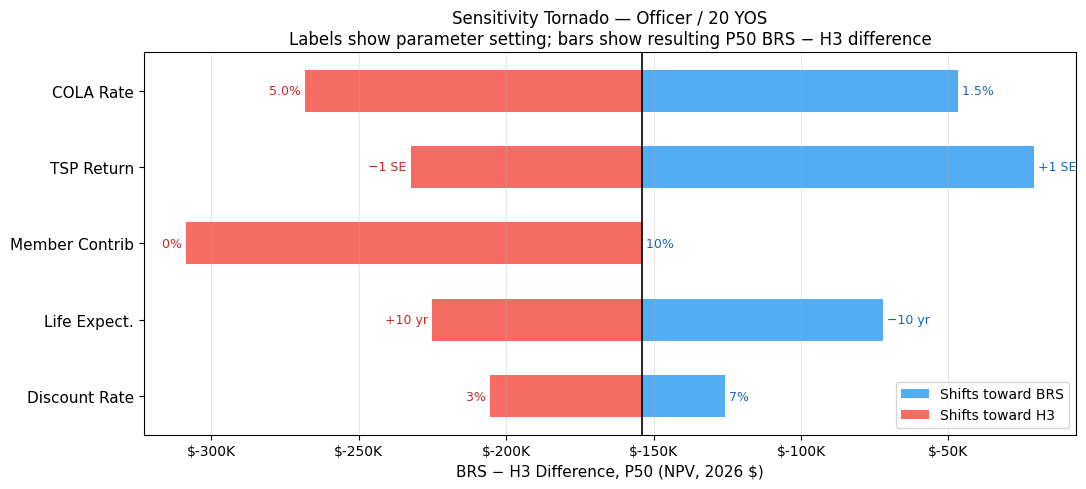

In [8]:
params = [
    "TSP Return",
    "COLA Rate",
    "Discount Rate",
    "Life Expect.",
    "Member Contrib",
]
param_labels = {
    "TSP Return":     ("−1 SE", "+1 SE"),
    "COLA Rate":      ("1.5%", "5.0%"),
    "Discount Rate":  ("3%", "7%"),
    "Life Expect.":   ("−10 yr", "+10 yr"),
    "Member Contrib": ("0%", "10%"),
}
lows = np.array(
    [oat_p50[f"{p} (low)"] for p in params]
)
highs = np.array(
    [oat_p50[f"{p} (high)"] for p in params]
)
ranges = np.abs(highs - lows)
order = np.argsort(ranges)

BLUE = "#2196F3"
RED = "#F44336"
BLUE_DARK = "#1565C0"
RED_DARK = "#C62828"

fig, ax = plt.subplots(figsize=(11, 5))
for i, idx in enumerate(order):
    p = params[idx]
    lo, hi = lows[idx], highs[idx]
    lo_lbl, hi_lbl = param_labels[p]

    blue_x = max(lo, hi)
    red_x = min(lo, hi)
    blue_lbl = lo_lbl if lo >= hi else hi_lbl
    red_lbl = hi_lbl if lo >= hi else lo_lbl

    blue_w = blue_x - baseline_p50
    red_w = red_x - baseline_p50

    ax.barh(
        i, blue_w, left=baseline_p50,
        color=BLUE, alpha=0.78, height=0.55,
        label="Shifts toward BRS" if i == 0 else "",
    )
    ax.barh(
        i, red_w, left=baseline_p50,
        color=RED, alpha=0.78, height=0.55,
        label="Shifts toward H3" if i == 0 else "",
    )
    ax.text(
        blue_x, i, f" {blue_lbl}",
        va="center", ha="left",
        fontsize=9, color=BLUE_DARK,
    )
    ax.text(
        red_x, i, f"{red_lbl} ",
        va="center", ha="right",
        fontsize=9, color=RED_DARK,
    )

ax.axvline(
    baseline_p50, color="black", lw=1.2, zorder=5
)
ax.set_yticks(range(len(params)))
ax.set_yticklabels(
    [params[i] for i in order], fontsize=11
)
fmt = mticker.FuncFormatter(
    lambda x, _: f"${x/1_000:.0f}K"
)
ax.xaxis.set_major_formatter(fmt)
ax.set_xlabel(
    "BRS − H3 Difference, P50 (NPV, 2026 $)",
    fontsize=11,
)
ax.set_title(
    "Sensitivity Tornado — Officer / 20 YOS\n"
    "Labels show parameter setting; bars show resulting"
    " P50 BRS − H3 difference",
    fontsize=12,
)
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### OAT Interpretation — Officer / 20 YOS

Baseline BRS − H3 difference P50: **−\$153,948**
(constant 2026 \$; rolling 30-yr average COLA basis).

**COLA rate is now the largest driver** (~\$222K range),
narrowly ahead of TSP returns. The single COLA draw does
triple duty — basic-pay growth, pension COLA, and the 2026-\$
deflator — and H3's larger multiplier (50% vs 40% at 20 YOS)
gains more from inflation in absolute dollars. Low COLA
(1.5%) narrows the difference to −\$47K; high COLA (5.0%)
widens it to −\$268K.

**TSP return rate is a close second** (~\$211K range). A
−1 SE shift widens the difference to −\$232K; +1 SE narrows
it to −\$21K — near zero, but the sign does not flip even
under the favorable return bound.

**Member contribution is third** (~\$155K range, one-sided).
At 0% member contribution, BRS receives only the 1% automatic
government contribution and H3 members contribute nothing —
the difference widens to −\$309K as the pension formula gap
dominates. At 10% the result is identical to baseline
(Δ = \$0): past 5%, the match is fully captured and extra
contributions add equally to both systems.

**Life expectancy is fourth** (~\$153K range, essentially tied
with member contribution). At −10 years the difference
narrows to −\$72K — the TSP lump sum is paid at age 60
regardless of longevity while H3's pension stream is cut
short. At +10 years it widens to −\$225K as the larger
pension compounds over more years.

**Discount rate matters least** (~\$80K range) but is not
negligible: 3% widens the difference to −\$205K and 7%
narrows it to −\$126K. The pension stream is longer-dated
than the TSP lump sum, so cheaper discounting of the future
favors H3.


### Female life tables — targeted sensitivity

The baseline uses SSA 2022 **male** tables (~83% of the
active force is male). Women outlive men by ~4 years at the
relevant separation ages, and a longer life means more years
of the inflation-protected pension — favoring High-Three.
Because `run_scenario` uses only the expected death age at
the separation age (with a fixed 13-yr std), passing the
male-to-female gap as `death_age_offset` reproduces female
tables exactly for the anchor scenario.

**Interpretation:** female tables (+4.1 yr at sep age 42)
deepen the Officer/20 median from −\$154K to −\$185K — a
−\$31K (~20%) shift toward High-Three, sitting comfortably
inside the ±10-yr OAT life-expectancy band (~\$153K range,
which covers the male–female gap almost 4× over). A
population-weighted blend (~17.5% female) would move the
baseline by under \$6K, so gender is treated as a targeted
sensitivity rather than a full model dimension.


In [9]:
le_row = life_df.loc[
    life_df["Age"] == ENTRY_AGES[ANC_PROFILE] + ANC_YOS
].iloc[0]
FEMALE_GAP = float(
    le_row["FemaleTotalAge"] - le_row["MaleTotalAge"]
)

female_out = _run_anchor(dao=FEMALE_GAP)
female_p50 = float(
    np.percentile(female_out["brs_adv"], 50)
)

print(
    f"Sep age {int(le_row['Age'])}: male total age "
    f"{le_row['MaleTotalAge']:.1f}, female "
    f"{le_row['FemaleTotalAge']:.1f}"
    f"  (gap +{FEMALE_GAP:.1f} yr)"
)
print(
    f"Officer/20 BRS - H3 P50, male tables:   "
    f"${baseline_p50:,.0f}"
)
print(
    f"Officer/20 BRS - H3 P50, female tables: "
    f"${female_p50:,.0f}"
)
shift = female_p50 - baseline_p50
print(f"Shift: ${shift:,.0f}")
rng_le = abs(
    oat_p50["Life Expect. (high)"]
    - oat_p50["Life Expect. (low)"]
)
print(
    f"Context: +/-10 yr OAT life-expectancy range"
    f" is ${rng_le:,.0f}"
)


Sep age 42: male total age 77.9, female 82.0  (gap +4.1 yr)
Officer/20 BRS - H3 P50, male tables:   $-153,948
Officer/20 BRS - H3 P50, female tables: $-184,653
Shift: $-30,706
Context: +/-10 yr OAT life-expectancy range is $152,811


## 3. Scenario Analysis

Four named scenarios are run across all 52 valid
(profile, sep_yos) combinations to show how the BRS/H3
crossover point moves under jointly adverse or favorable
conditions.

| Scenario | Returns | COLA | Discount | Member contrib |
|---|---|---|---|---|
| **Base** | empirical | 30-yr avg CPI | 5% | 5% (BRS 10%) |
| **Bull Market** | +2 pp | 1.5% | 4% | 5% (BRS 10%) |
| **Bear Market** | −2 pp | 5.0% | 6% | 5% (BRS 10%) |
| **Low Participation** | empirical | 30-yr avg CPI | 5% | 0% (BRS 1% auto) |

The ±2 pp return shift is a deliberate market-regime stress —
a sustained good or bad market — applied uniformly to all
funds. It is **not** the same construct as the OAT TSP-return
bound in §2, which uses a per-fund ±1 SE to represent
statistical uncertainty in the historical mean. Here the goal
is a legible "good market vs. bad market" contrast, so a
round, uniform value is preferred over fund-specific bounds.
±2 pp happens to fall between the per-fund SEs (wider than
L Income's 0.76 pp, narrower than L 2050's 3.03 pp).

*Low Participation* represents members who make no voluntary
TSP contributions. BRS still provides the 1% automatic
government contribution; H3 provides nothing. The government
TSP advantage collapses from 5% to 1% of pay.

N = 20,000 iterations per (scenario, profile, sep_yos),
matching notebooks 03b and 04. `RNG_SEED = 42` is held
constant across all scenarios so that differences between
scenario curves reflect parameter changes, not random noise.

In [10]:
N_SCEN = 20_000

scenarios = {
    "Base": dict(
        fs=fund_stats,
        cs=cola_stats,
        dr=0.05,
        dao=0.0,
        mbr=0.05,
        pay=pay_df,
    ),
    "Bull Market": dict(
        fs=shift_fund_means(fund_stats, +0.02),
        cs={"mean": 0.015, "std": cola_stats["std"]},
        dr=0.04,
        dao=0.0,
        mbr=0.05,
        pay=pay_df,
    ),
    "Bear Market": dict(
        fs=shift_fund_means(fund_stats, -0.02),
        cs={"mean": 0.050, "std": cola_stats["std"]},
        dr=0.06,
        dao=0.0,
        mbr=0.05,
        pay=pay_df,
    ),
    "Low Participation": dict(
        fs=fund_stats,
        cs=cola_stats,
        dr=0.05,
        dao=0.0,
        mbr=MBR_LOW,
        pay=pay_df,
    ),
}

In [11]:
scen_p50 = {}
for scen_name, p in scenarios.items():
    print(f"Running scenario: {scen_name} ...")
    scen_p50[scen_name] = {}
    for profile, yos_list in VALID_SCENARIOS.items():
        scen_p50[scen_name][profile] = {}
        for yos in yos_list:
            out = run_scenario(
                profile, yos,
                p["pay"], life_df,
                p["fs"], p["cs"],
                ENTRY_AGES,
                n_iter=N_SCEN,
                discount_rate=p["dr"],
                seed=RNG_SEED,
                death_age_offset=p["dao"],
                member_rate=p["mbr"],
            )
            scen_p50[scen_name][profile][yos] = float(
                np.percentile(out["brs_adv"], 50)
            )
print("Done.")

Running scenario: Base ...


Running scenario: Bull Market ...


Running scenario: Bear Market ...


Running scenario: Low Participation ...


Done.


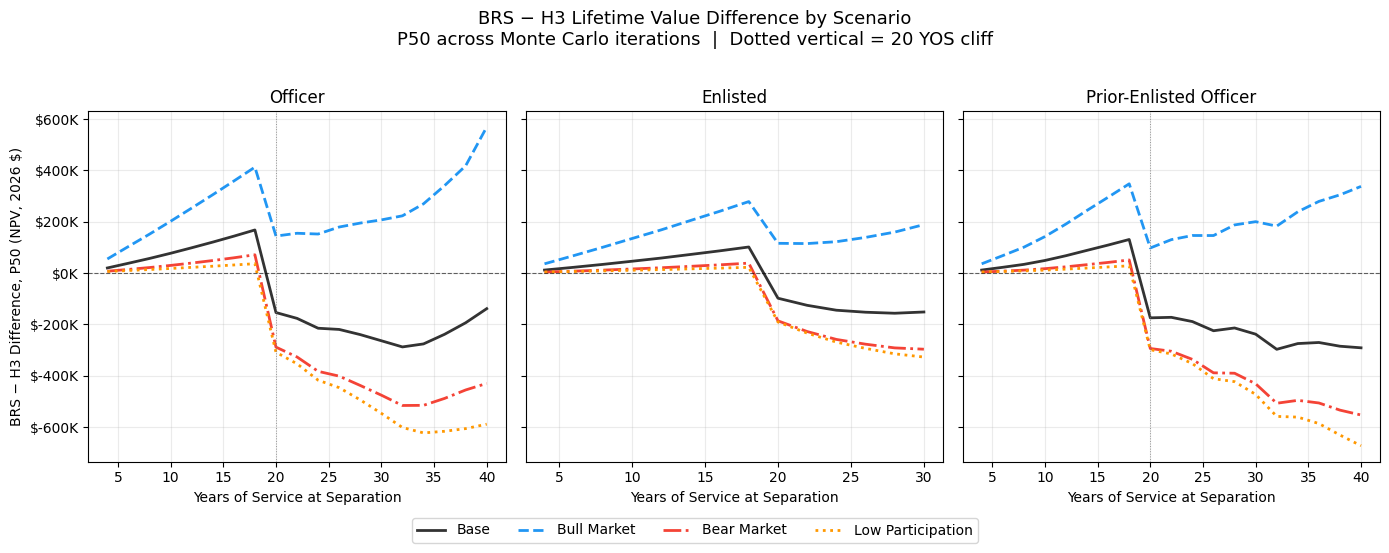

In [12]:
SCEN_COLORS = {
    "Base": "#333333",
    "Bull Market": "#2196F3",
    "Bear Market": "#F44336",
    "Low Participation": "#FF9800",
}
SCEN_LS = {
    "Base": "-",
    "Bull Market": "--",
    "Bear Market": "-.",
    "Low Participation": ":",
}
PROFILE_TITLES = {
    "Officer": "Officer",
    "Enlisted": "Enlisted",
    "PriorEnlistedOfficer": "Prior-Enlisted Officer",
}

fig, axes = plt.subplots(
    1, 3, figsize=(14, 5), sharey=True
)

for ax, (profile, title) in zip(
    axes, PROFILE_TITLES.items()
):
    yos_list = VALID_SCENARIOS[profile]
    for scen_name in scenarios:
        p50_vals = [
            scen_p50[scen_name][profile][y]
            for y in yos_list
        ]
        ax.plot(
            yos_list, p50_vals,
            label=scen_name,
            color=SCEN_COLORS[scen_name],
            ls=SCEN_LS[scen_name],
            lw=2.0,
        )
    ax.axhline(
        0, color="black", lw=0.8, ls="--", alpha=0.6
    )
    if profile in ("Officer", "PriorEnlistedOfficer"):
        ax.axvline(
            20, color="gray", lw=0.7,
            ls=":", alpha=0.8,
        )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(
        "Years of Service at Separation", fontsize=10
    )
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f"${x/1_000:.0f}K"
        )
    )
    ax.grid(alpha=0.25)

axes[0].set_ylabel(
    "BRS − H3 Difference, P50 (NPV, 2026 $)",
    fontsize=10,
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center", ncol=4, fontsize=10,
    bbox_to_anchor=(0.5, -0.06),
)
fig.suptitle(
    "BRS − H3 Lifetime Value Difference by Scenario\n"
    "P50 across Monte Carlo iterations  |  "
    "Dotted vertical = 20 YOS cliff",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

### Scenario Interpretation

**Short service (10 YOS): difference positive (BRS higher)
in every scenario.** Officer P50 ranges from +\$30K (Bear
Market) to +\$202K (Bull Market); Enlisted from +\$16K to
+\$134K. The government TSP contribution is the only deferred
compensation before the pension vests, so all scenarios put
BRS ahead at 10 YOS — though Low Participation cuts the
Officer figure from +\$77K (Base) to +\$18K.

**At 20 YOS the sign is scenario-dependent for all
profiles.** Under Base, the difference is negative (H3
higher) for all three (Officer −\$154K, Enlisted −\$98K,
PEO −\$175K). Bull Market flips every profile positive —
Officer +\$144K, Enlisted +\$116K, PEO +\$98K — as the +2 pp
return shift, low 1.5% COLA, and 4% discount rate jointly
favor the TSP. Bear Market widens the difference (Officer
−\$289K, PEO −\$294K).

**Long service (30 YOS): the Base-case H3 advantage keeps
growing.** Officer −\$264K, PEO −\$238K under Base — there
is no late-career BRS recovery under the consistent
pay-growth model. Bull Market still flips positive (Officer
+\$207K, PEO +\$200K); Bear Market reaches −\$476K (Officer)
and −\$431K (PEO); Low Participation is the worst case at
−\$546K / −\$473K.

**Low Participation** (member contributes 0%; BRS receives
only the 1% automatic government contribution, H3 receives
nothing) produces the most H3-favorable outcomes at every
career length — the government contribution falls from 5%
to 1% of pay, which compounds dramatically over long
careers. At Officer 20 YOS the difference falls from
−\$154K to −\$309K.


## 4. Separation-Distribution Sensitivity (per-entrant fiscal)

The fiscal comparison in nb04 weights each YOS scenario by
its DoD actuarial separation probability, held fixed
throughout. This section asks one question: **how sensitive
is expected per-entrant DoD savings to that assumed
separation timing?**

This is a *mechanical what-if*, **not** a behavioral
prediction. BRS may plausibly shift separations earlier or
toward mid-career (TSP vests at 2 years and is portable),
but this notebook does not model that behavior — it only
reshapes the separation weights by hand and recomputes the
expectation. No claim is made that BRS *causes* the shift.

**Scope (per CLAUDE.md):**
- Per-entrant metrics only — expected H3_GovtCost,
  BRS_GovtCost, and DoD_Savings per entrant. Force size and
  accessions are out of scope for this cut.
- Per-scenario costs (`fiscal_results.csv`) are unchanged;
  03a / 03b / the Monte Carlo are **not** re-run. Only the
  separation weights are reshaped.

**Hypothesis scenario** (magnitudes are assumptions, not
data). The separation distribution is grouped into four
career phases, and probability mass is moved between them:

| Phase | YOS | Δ mass | Rationale |
|---|---|---|---|
| First term | ≤ 6 | −4 pts | more retained past first term |
| Early mid | 7–12 | +4 pts | more mid-career separation |
| Late mid | 13–19 | +2 pts | more pre-20 separation |
| Career | 20+ | −2 pts | slightly fewer reach 20 |

Each phase's net delta is distributed across the modeled YOS
inside it in proportion to baseline weight, so within-phase
shape is preserved and the shift adapts to each profile. The
deltas sum to zero, so the weights stay a probability
distribution. Because expected cost is linear in the weights,
DoD savings moves monotonically from baseline to full shift
with no threshold or reversal (we report the two endpoints).

The first cell loads nb04's persisted separation weights
(`scenario_weights.csv`) and
confirms it reproduces nb04's baseline per-entrant costs
before any reshaping.

In [13]:
fiscal = pd.read_csv(f"{BASE}/fiscal_results.csv")

# Separation weights persisted by nb04: P(sep at modeled YOS),
# binned to the nearest scenario; sums to 1 per profile.
weights_df = pd.read_csv(f"{BASE}/scenario_weights.csv")
sep_weights = {
    prof: sub.set_index("SepYOS")["Weight"]
    for prof, sub in weights_df.groupby("Profile")
}


def expected_perentrant(weights, profile, col):
    """Separation-weighted expected per-entrant value."""
    sub = (
        fiscal[fiscal["Profile"] == profile]
        .set_index("SepYOS")
    )
    return float(
        (weights * sub.reindex(weights.index)[col]).sum()
    )


print(
    "Baseline expected per-entrant cost"
    " (reproduces nb04):"
)
for prof in VALID_SCENARIOS:
    w = sep_weights[prof]
    h3 = expected_perentrant(w, prof, "H3_GovtCost")
    brs = expected_perentrant(w, prof, "BRS_GovtCost")
    ds = expected_perentrant(w, prof, "DoD_Savings")
    print(
        f"  {prof:22}"
        f" H3 ${h3/1000:>7,.1f}K"
        f"  BRS ${brs/1000:>7,.1f}K"
        f"  DoD savings ${ds/1000:>6,.1f}K"
    )


Baseline expected per-entrant cost (reproduces nb04):
  Officer                H3 $  893.9K  BRS $  798.6K  DoD savings $  95.3K
  Enlisted               H3 $  228.8K  BRS $  204.8K  DoD savings $  24.1K
  PriorEnlistedOfficer   H3 $  802.6K  BRS $  701.4K  DoD savings $ 101.2K


In [14]:
def apply_weight_shift(base_weights, adjustments):
    """
    Reshape a separation-weight Series by a zero-sum dict.

    Parameters
    ----------
    base_weights : pd.Series  indexed by SepYOS, sums to 1
    adjustments  : dict[int, float]  SepYOS -> delta;
                   the deltas must sum to 0

    Returns
    -------
    pd.Series  shifted weights (sums to 1, all >= 0)
    """
    assert abs(sum(adjustments.values())) < 1e-9, (
        "adjustments must be zero-sum"
    )
    w = base_weights.copy()
    for yos, delta in adjustments.items():
        w[yos] = w[yos] + delta
    assert (w >= -1e-12).all(), (
        "shift drove a weight negative"
    )
    assert abs(w.sum() - 1.0) < 1e-9
    return w


# The hypothesis is expressed at the career-phase level rather
# than at hand-picked YOS points: more retention past the
# first term, more separation in mid-career, and slightly
# fewer reaching 20. BAND_DELTAS are net probability mass
# moved between phases and must sum to zero.
BANDS = {
    "First term (≤6)":  lambda y: y <= 6,
    "Early mid (7–12)": lambda y: 7 <= y <= 12,
    "Late mid (13–19)": lambda y: 13 <= y <= 19,
    "Career (20+)":     lambda y: y >= 20,
}
BAND_DELTAS = {
    "First term (≤6)":  -0.04,
    "Early mid (7–12)": +0.04,
    "Late mid (13–19)": +0.02,
    "Career (20+)":     -0.02,
}


def band_deltas_to_yos(base_weights, band_deltas, bands):
    """
    Convert band-level deltas to a per-YOS zero-sum dict.

    Each band's delta is spread across the modeled YOS in that
    band in proportion to their baseline weight, so within-band
    shape is preserved and the shift adapts to each profile's
    own distribution.
    """
    adj = {}
    for band, delta in band_deltas.items():
        members = [
            y for y in base_weights.index if bands[band](y)
        ]
        band_mass = float(base_weights[members].sum())
        for y in members:
            adj[y] = adj.get(y, 0.0) + delta * (
                base_weights[y] / band_mass
            )
    return adj


print(
    "Full-scenario shift vs. baseline"
    " (per-entrant DoD savings):"
)
for prof in VALID_SCENARIOS:
    w0 = sep_weights[prof]
    w1 = apply_weight_shift(
        w0, band_deltas_to_yos(w0, BAND_DELTAS, BANDS)
    )
    base = expected_perentrant(w0, prof, "DoD_Savings")
    full = expected_perentrant(w1, prof, "DoD_Savings")
    print(
        f"  {prof:22}"
        f" baseline ${base/1000:>6,.1f}K"
        f"  ->  shifted ${full/1000:>6,.1f}K"
        f"  (Δ ${(full - base)/1000:>+6,.1f}K)"
    )

Full-scenario shift vs. baseline (per-entrant DoD savings):
  Officer                baseline $  95.3K  ->  shifted $  87.4K  (Δ $  -8.0K)
  Enlisted               baseline $  24.1K  ->  shifted $  19.4K  (Δ $  -4.6K)
  PriorEnlistedOfficer   baseline $ 101.2K  ->  shifted $  94.2K  (Δ $  -7.0K)


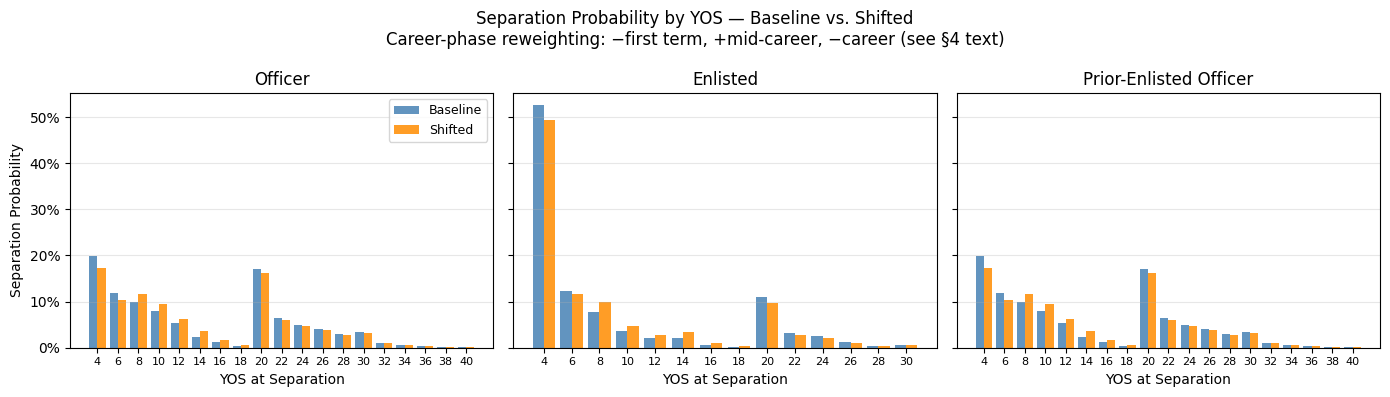

In [15]:
fig, axes = plt.subplots(
    1, 3, figsize=(14, 4), sharey=True
)

bar_w = 0.4
for ax, prof in zip(axes, VALID_SCENARIOS):
    w0 = sep_weights[prof]
    w1 = apply_weight_shift(
        w0, band_deltas_to_yos(w0, BAND_DELTAS, BANDS)
    )
    x = np.arange(len(w0))
    ax.bar(
        x - bar_w / 2, w0.values, width=bar_w,
        label="Baseline", color="steelblue", alpha=0.85,
    )
    ax.bar(
        x + bar_w / 2, w1.values, width=bar_w,
        label="Shifted", color="darkorange", alpha=0.85,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(w0.index.astype(str), fontsize=8)
    ax.set_xlabel("YOS at Separation")
    ax.set_title(PROFILE_TITLES[prof])
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{v:.0%}")
    )
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Separation Probability")
axes[0].legend(fontsize=9)
fig.suptitle(
    "Separation Probability by YOS — Baseline vs. Shifted\n"
    "Career-phase reweighting: −first term, +mid-career,"
    " −career (see §4 text)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

### Separation-Distribution Interpretation

**Validation.** With baseline weights the loaded
`scenario_weights.csv` reproduces nb04's expected per-entrant
cost exactly — Officer \$95.3K, Enlisted \$24.1K, PEO \$101.2K
DoD savings — confirming the reshaping operates on the same
distribution nb04 used.

**The result is robust to the assumed shift.** Moving mass
toward earlier and mid-career separation erodes expected
per-entrant DoD savings but never changes its sign:

| Profile | Baseline | Full shift | Δ | % |
|---|---|---|---|---|
| Officer | \$95.3K | \$87.4K | −\$8.0K | −8.3% |
| Enlisted | \$24.1K | \$19.4K | −\$4.6K | −19.3% |
| PEO | \$101.2K | \$94.2K | −\$7.0K | −6.9% |

Because expected cost is linear in the weights, the full
shift is the endpoint of a straight line from baseline —
there is no threshold or reversal in between.

**Mechanism (Officer, −\$8.0K decomposed by phase).** The
largest term is the **−2 pts off the career (20+) phase
(−\$5.4K)**: most of that mass sits at YOS 20, where BRS is
markedly cheaper for DoD (DoD_Savings +\$220K at Officer/20)
because H3's 50% pension dwarfs BRS's 40% pension plus TSP
cost. Pulling mass away from it removes the biggest positive
contribution. The mid-career additions are jointly
comparable: **+4 pts early mid (−\$1.5K)** and **+2 pts late
mid (−\$1.5K)** both add weight to members who separate
before any pension vests, where DoD books only the BRS TSP
cost as a negative saving. The **−4 pts off the first term
works the other way (+\$0.5K)** — removing very early
separatees trims a small negative — but it is far too small
to offset the other three.

**Enlisted is the most sensitive in percentage terms**
(−19% vs −7% to −8% for the officer profiles) because its
baseline saving is small while its first-term mass is large
(~65% of entrants below 7 YOS), so the same proportional
reshaping is a larger share of a smaller number.

**Bottom line:** the fiscal conclusion from nb04 — BRS is
roughly 10% cheaper for DoD per entrant — holds across this
separation-timing what-if. A plausible behavioral shift
toward earlier and mid-career separation would narrow the
savings, not erase it. This is a sensitivity bound, not a
prediction; actual behavioral effects are out of scope
(see CLAUDE.md).


## 5. Summary Tables

OAT deltas (P50 BRS − H3 difference vs. baseline) and
scenario P50 BRS − H3 difference at the Officer / 20 YOS
anchor point.

In [16]:
rows = []
for p in params:
    lo = oat_p50[f"{p} (low)"]
    hi = oat_p50[f"{p} (high)"]
    rows.append({
        "Parameter": p,
        "Low P50 ($)": f"{lo:,.0f}",
        "Baseline P50 ($)": f"{baseline_p50:,.0f}",
        "High P50 ($)": f"{hi:,.0f}",
        "Range ($)": f"{abs(hi - lo):,.0f}",
    })

oat_df = (
    pd.DataFrame(rows)
    .assign(**{"Range ($)": lambda d: d["Range ($)"]
               .str.replace(",", "").astype(int)})
    .sort_values("Range ($)", ascending=False)
    .assign(**{"Range ($)": lambda d:
               d["Range ($)"].apply(lambda x: f"{x:,}")})
    .reset_index(drop=True)
)

display(oat_df)

,Parameter,Low P50 ($),Baseline P50 ($),High P50 ($),Range ($)
0,COLA Rate,"-46,659","-153,948","-268,363","221,703"
1,TSP Return,"-232,396","-153,948","-20,979","211,417"
2,Member Contrib,"-308,551","-153,948","-153,948","154,603"
3,Life Expect.,"-72,203","-153,948","-225,013","152,811"
4,Discount Rate,"-205,497","-153,948","-125,774","79,723"


In [17]:
scen_rows = []
for scen_name in scenarios:
    for profile in VALID_SCENARIOS:
        for yos in [10, 20, 30]:
            if yos not in scen_p50[scen_name][profile]:
                continue
            v = scen_p50[scen_name][profile][yos]
            scen_rows.append({
                "Scenario": scen_name,
                "Profile": profile,
                "SepYOS": yos,
                "BRS − H3 P50 ($)": f"{v:,.0f}",
            })

scen_tbl = pd.DataFrame(scen_rows)
display(
    scen_tbl.pivot_table(
        index=["Scenario"],
        columns=["Profile", "SepYOS"],
        values="BRS − H3 P50 ($)",
        aggfunc="first",
    )
)

Profile           Enlisted                      Officer                      \
SepYOS                  10        20        30       10        20        30   
Scenario                                                                      
Base                45,875   -98,161  -151,775   76,883  -153,948  -263,785   
Bear Market         15,778  -186,286  -296,704   29,592  -288,582  -475,711   
Bull Market        134,369   115,653   188,474  201,527   143,918   206,903   
Low Participation   10,757  -190,783  -327,311   17,722  -308,551  -546,492   

Profile           PriorEnlistedOfficer                      
SepYOS                              10        20        30  
Scenario                                                    
Base                            48,839  -174,575  -238,138  
Bear Market                     16,891  -293,998  -431,404  
Bull Market                    141,872    97,543   199,925  
Low Participation               11,347  -298,699  -472,727